# Métricas do sistemas
---

### Bibliotecas

---

Caso não consiga instalar execute `pip install -r requirements.txt` no terminal

In [57]:
!uv pip install -r ../requirements.txt

Using Python 3.10.11 environment at: C:\Users\Victo\Desktop\Ufal\obi-benchmarking\.venv
Checked 10 packages in 26ms


In [58]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json

In [59]:
path_database = Path("../database")
questions_path = []
        
for folder in list(path_database.iterdir()):
    if folder.is_dir():
        questions_path.append(folder)
        
problems = []
questions_name = []
for question_path in questions_path:
    
    path_imgs = question_path / "imgs"
    path_test_cases = question_path / "test_cases"
    
    if path_test_cases.exists() and path_imgs.exists():
        questions_name.append(question_path.name)
        problems.append(json.loads(Path(question_path / "problem.json").read_text(encoding="utf-8")))
        
print(f"Quantidade de problemas com imagens: {len(problems)}")

Quantidade de problemas com imagens: 181


In [60]:
for problem in problems:
    print(problem["title"])

Acelerador de partículas
Amigos
Arco e flecha
Atlanta
Atletismo
Avenida
Avião
Baldes
Basquete de robôs
Bingo!
Bolas
Bombom
Bondinho
Brigadeiros
Burocracia
Cabo de guerra
Cadeado
Cadeiras do auditório
Caixinha de palitos
Calçada Imperial
Caminho das Pontes
Caminhos do reino
Campeonato
Campo de Minhocas
Campo Minado
Capitais
Carro elétrico
Cartas
Casamento de inteiros
Castelos da Nlogônia
Catálogo de Músicas
Cavalos
Caça ao Tesouro
Caçadores de Mitos
Chinelos
Chocolate
Chocolate em barra
Chuva
Chuva
Cinco
Cinema
Competição de chocolate
Computador
Construção de Rodovia
Conta de água
Copa
Copa do Mundo
Corredor
Cortando o Papel
Costa
Cubo Preto
Cubra os Furos
Cápsulas
Câmara de Compensação
Câmeras
Dança de Formatura
Dança Indígena
Dario e Xerxes
Dengue
Diagonal
Distância entre amigos
Dividindo o império
Dobradura
Dominó
Dominó
Dona Minhoca
Duende Perdido
Elevador
Entrega de Caixas
Escada perfeita
Escher
Estoque
Falta uma
Fast-Food
Fila
Fissura Perigosa
Fitas Verde-amarelas
Floresta
Flíper


In [61]:
df_problems = pd.DataFrame(problems)
counts_difficulty = {}

for d in df_problems["difficulty"].unique():
    cases = df_problems[df_problems["difficulty"] == d]
    counts_difficulty[d] = len(cases)
    
print(counts_difficulty)

{'Fácil': 67, 'Médio': 81, 'Difícil': 33}


[67, 81, 33]
['Fácil', 'Médio', 'Difícil']


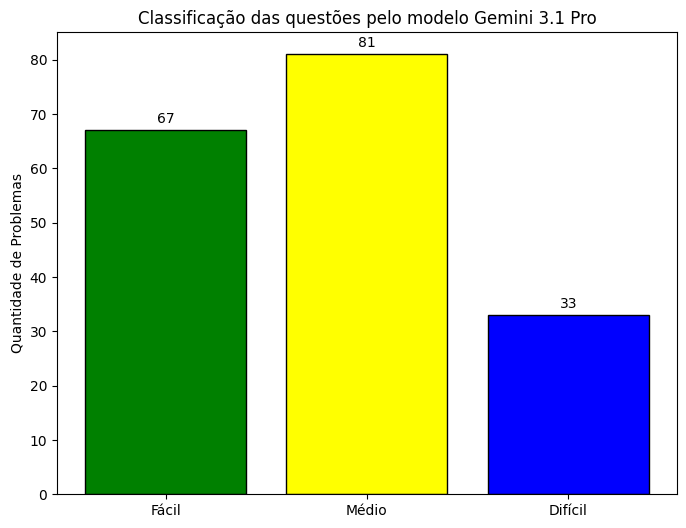

In [62]:
X = ["Fácil", "Médio", "Difícil"]
y = [counts_difficulty[x] for x in X]

print(y)
print(X)
plt.figure(figsize=(8, 6))

bar_plot = plt.bar(X, y, color=['green', 'yellow', 'blue'], edgecolor='black')

plt.bar_label(bar_plot, padding=3)

plt.title("Classificação das questões pelo modelo Gemini 3.1 Pro")
plt.ylabel('Quantidade de Problemas')
plt.show()

### PROMPT: QUESTÕES COM IMAGENS NA BASE64 vs QUESTÕES SEM IMAGENS
---

In [63]:
files_path = Path("../output/multimodal/results/")
dataset = {}

count_total_tokens = {}

for path in files_path.rglob("*"):
    if not path.is_file():
        continue
    
    df = pd.read_csv(path)
    
    name = path.name.replace(".csv", "")
    count_total_tokens[name] = 0
    
    dataset[name] = df
    
    for value in df["total_tokens"]:
        count_total_tokens[name] += value
        
for key, value in count_total_tokens.items():
    print(f"file: {key} | total de tokens: {value}")

file: results_anthropic_claude_sonnet_4_6_python_zero_img | total de tokens: 370949
file: results_anthropic_claude_sonnet_4_6_python_zero_noimg | total de tokens: 307314
file: results_google_gemini_3_1_pro_preview_python_zero_img | total de tokens: 1183470
file: results_google_gemini_3_1_pro_preview_python_zero_noimg | total de tokens: 928250
file: results_gpt_5_4_python_zero_img | total de tokens: 240511
file: results_gpt_5_4_python_zero_noimg | total de tokens: 203283
file: results_mistralai_mistral_small_2603_python_zero_img | total de tokens: 263588
file: results_mistralai_mistral_small_2603_python_zero_noimg | total de tokens: 219431
file: results_x_ai_grok_4_20_python_zero_img | total de tokens: 324413
file: results_x_ai_grok_4_20_python_zero_noimg | total de tokens: 354468


In [64]:
def success_rate_in_case_tests(files_path: Path = Path('../output/multimodal/results/'), type: str = '_img'):
    
    dataset = {}
    for path in files_path.rglob('*'):
        if not path.is_file():
            continue

        parts = str(path).split("results_")
        if len(parts) < 2:
            continue
                    
        if not (type in path.name):
            continue
            
        if path.stat().st_size == 0:
            print(f"⚠️ Arquivo vazio ignorado: {path.name}")
            continue

        try:
            df = pd.read_csv(path)
            model_name = path.name.replace(".csv", "")
            
            print(model_name)
            if model_name not in dataset:
                dataset[model_name] = df
            else:
                dataset[model_name] = pd.concat([dataset[model_name], df], ignore_index=True)
            
        except ValueError as e:
            print(f"Erro de ValueError (JSON malformado) no arquivo: {path.name}")
            print(f"   -> Detalhe: {e}")
        except Exception as e:
            print(f"Erro inesperado ao ler {path.name}: {e}")

    count = 0
    keys = list(dataset.keys())
    for data in dataset[keys[0]]["total_test_cases"]:
        count += data
    
    print("Total de caso testes: ", count)
    rows = []
    for model, data in dataset.items():
        rows.append({
            "Modelo": model,
            "AC":  data["AC"].sum()  / count,
            "WA":  data["WA"].sum()  / count,
            "RE":  data["RE"].sum()  / count,
            "TLE": data["TLE"].sum() / count,
            "CE":  data["CE"].sum()  / count,
        })

    df_results = pd.DataFrame(rows)

    display(
        df_results.style
        .format({
            "AC":  "{:.2%}",
            "WA":  "{:.2%}",
            "RE":  "{:.2%}",
            "TLE": "{:.2%}",
            "CE":  "{:.2%}",
        })
    )

In [65]:
#colocar com _type
success_rate_in_case_tests(type='_img')

results_anthropic_claude_sonnet_4_6_python_zero_img
results_google_gemini_3_1_pro_preview_python_zero_img
results_gpt_5_4_python_zero_img
results_mistralai_mistral_small_2603_python_zero_img
results_x_ai_grok_4_20_python_zero_img
Total de caso testes:  6708


,Modelo,AC,WA,RE,TLE,CE
0,results_anthropic_claude_sonnet_4_6_python_zero_img,80.41%,5.32%,11.17%,3.10%,0.00%
1,results_google_gemini_3_1_pro_preview_python_zero_img,96.41%,2.89%,0.42%,0.28%,0.00%
2,results_gpt_5_4_python_zero_img,78.86%,17.87%,2.24%,1.03%,0.00%
3,results_mistralai_mistral_small_2603_python_zero_img,55.72%,32.98%,6.72%,4.58%,0.00%
4,results_x_ai_grok_4_20_python_zero_img,65.09%,23.02%,7.71%,4.19%,0.00%


In [66]:
success_rate_in_case_tests(type='_noimg')

results_anthropic_claude_sonnet_4_6_python_zero_noimg
results_google_gemini_3_1_pro_preview_python_zero_noimg
results_gpt_5_4_python_zero_noimg
results_mistralai_mistral_small_2603_python_zero_noimg
results_x_ai_grok_4_20_python_zero_noimg
Total de caso testes:  6708


,Modelo,AC,WA,RE,TLE,CE
0,results_anthropic_claude_sonnet_4_6_python_zero_noimg,81.25%,6.80%,8.35%,3.61%,0.00%
1,results_google_gemini_3_1_pro_preview_python_zero_noimg,96.27%,2.92%,0.42%,0.39%,0.00%
2,results_gpt_5_4_python_zero_noimg,77.46%,19.07%,2.52%,0.95%,0.00%
3,results_mistralai_mistral_small_2603_python_zero_noimg,60.94%,29.77%,5.50%,3.79%,0.00%
4,results_x_ai_grok_4_20_python_zero_noimg,61.91%,23.27%,10.96%,3.86%,0.00%


In [67]:
def average(data):
    n = len(data)
    count = 0
    
    for value in data:
        count += value
        
    return float(count/n)

In [68]:
def per_ac_questions(data):
    n = len(data)
    count = 0
    for value in data["judge_predict"]:
        if value == "AC":
            count += 1
            
    return float(count/n)

In [69]:
def table_with_info(type: str = "_img"):
    files_path = Path("../output/multimodal/results/")

    dataset = {}

    for path in list(files_path.rglob('*')):        
        model = str(path).split("results_")[1]
        if not type in model:
            continue
        
        model = model.split("_python_zero")[0]
        
        dataset[model] = pd.read_csv(path)
    
    metrics = {}

    for key, data in dataset.items():
        
        row = {}
        
        hard_questions = data[data["difficulty"] == "Difícil"]
        row['hard_ac'] = per_ac_questions(hard_questions)
        
        medium_questions = data[data["difficulty"] == "Médio"]
        row['medium_ac'] = per_ac_questions(medium_questions)
        
        easy_questions = data[data["difficulty"] == "Fácil"]
        row['easy_ac'] = per_ac_questions(easy_questions)
        
        row['avg_tokens'] = average(data["total_tokens"])
        row['avg_cost'] = average(data["cost_prompt"])
        row['avg_create_code'] = average(data["llm_code_creation_time"])
        
        metrics[key] = row
    
    rows = []
    names_model = {
        "anthropic_claude_sonnet_4_6": "Claude Sonnet 4.6",
        "gpt_5_4": "GPT 5.4",
        "x_ai_grok_4_20": "Grok 4.20",
        "google_gemini_3_1_pro_preview": "Gemini 3.1 Pro",
        "mistralai_mistral_small_2603": "Mistral Small 4"
    }

    for key, data in metrics.items():
        rows.append({
            "Modelo":               names_model[key],
            "Fácil AC (%)":         data["easy_ac"] * 100,
            "Média AC (%)":         data["medium_ac"] * 100,
            "Difícil AC (%)":       data["hard_ac"] * 100,
            "Tokens (Média)":       data["avg_tokens"],
            "Custo Médio (US$)":    data["avg_cost"],
            "Tempo Médio (s)":      data["avg_create_code"], 
        })

    df = pd.DataFrame(rows).sort_values("Modelo").reset_index(drop=True)

    display(
        df.style
        .format({
            "Fácil AC (%)":       "{:.2f}",
            "Média AC (%)":       "{:.2f}",
            "Difícil AC (%)":     "{:.2f}",
            "Tokens (Média)":     "{:.0f}",
            "Custo Médio (US$)":  "{:.4f}",
            "Tempo Médio (s)":    "{:.0f}",
        })
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])
        .hide(axis="index")
    )

In [70]:
table_with_info("_img")

Modelo,Fácil AC (%),Média AC (%),Difícil AC (%),Tokens (Média),Custo Médio (US$),Tempo Médio (s)
Claude Sonnet 4.6,83.58,71.60,30.30,2049,0.0148,12
GPT 5.4,82.09,69.14,33.33,1329,0.0065,4
Gemini 3.1 Pro,97.01,87.65,78.79,6539,0.0567,39
Grok 4.20,73.13,53.09,15.15,1792,0.0061,7
Mistral Small 4,61.19,41.98,12.12,1456,0.0018,3


In [71]:
table_with_info("_noimg")

Modelo,Fácil AC (%),Média AC (%),Difícil AC (%),Tokens (Média),Custo Médio (US$),Tempo Médio (s)
Claude Sonnet 4.6,77.61,75.31,36.36,1698,0.0121,9
GPT 5.4,80.60,67.90,27.27,1123,0.0059,4
Gemini 3.1 Pro,97.01,88.89,75.76,5128,0.0520,38
Grok 4.20,61.19,53.09,18.18,1958,0.0078,9
Mistral Small 4,58.21,49.38,9.09,1212,0.0016,3


# Acertos por tópicos: grafos e programação dinâmica
---

In [72]:
total = 0

for key, data in dataset.items():
    total_cost = 0

    for count_test in data["cost_prompt"]:
        total_cost += count_test
    
    total += total_cost
    
    print(f"Total do custo [{key}]: U$ {total_cost:.2f}")
    
print(f"Valor gasto atualmente: U$ {total:.2f}")

Total do custo [results_anthropic_claude_sonnet_4_6_python_zero_img]: U$ 2.67
Total do custo [results_anthropic_claude_sonnet_4_6_python_zero_noimg]: U$ 2.19
Total do custo [results_google_gemini_3_1_pro_preview_python_zero_img]: U$ 10.26
Total do custo [results_google_gemini_3_1_pro_preview_python_zero_noimg]: U$ 9.42
Total do custo [results_gpt_5_4_python_zero_img]: U$ 1.17
Total do custo [results_gpt_5_4_python_zero_noimg]: U$ 1.07
Total do custo [results_mistralai_mistral_small_2603_python_zero_img]: U$ 0.32
Total do custo [results_mistralai_mistral_small_2603_python_zero_noimg]: U$ 0.29
Total do custo [results_x_ai_grok_4_20_python_zero_img]: U$ 1.10
Total do custo [results_x_ai_grok_4_20_python_zero_noimg]: U$ 1.41
Valor gasto atualmente: U$ 29.91


In [73]:
topics_unique = set()

for problem in problems:
    for topic in problem["topics"]:
        topics_unique.add(topic)
        
print(topics_unique)

{'busca em grade', 'árvore de fenwick', 'arrays', 'fórmulas', 'simulação', 'mediana', 'pré-processamento', 'convex hull trick', 'dfs', 'hashing', 'busca binária', 'matemática', 'implementação', 'Array', 'recursão', 'somas', 'dfs/bfs', 'componentes conexas', 'busca em grafos', 'Árvores', 'mapeamento', 'Interseção de Retângulos', 'busca exaustiva', 'lazy propagation', 'Árvore Geradora Mínima', 'Matemática', 'grafos', 'ordenação', 'teoria dos números', 'Programação Dinâmica', 'árvore geradora mínima', 'somas de prefixo', 'loops', 'arredondamento', 'Simulação', 'ad-hoc', 'Busca em Largura', 'Força Bruta', 'programação dinâmica', 'geometria', 'combinatória', 'estrutura de dados', 'algoritmo de dijkstra', 'contagem', 'Ad-hoc', 'diâmetro', 'dijkstra', 'Busca em Profundidade (DFS)', 'mathematics', 'matrizes', 'guloso', 'autômato celular', 'BFS/DFS', 'flood fill', 'Backtracking', 'algoritmos gulosos', 'componentes fortemente conexos', 'Geometria', 'condicionais', 'otimização', 'two pointers', '

In [74]:
topics = []

for problem in problems:
    if problem.get("topics") is not None:
        topics.extend(problem["topics"])

print(set(topics))

topics_grafos = [
    'grafos', 
    'ciclos em grafos', 
    'busca em largura', 
    'busca em profundidade',
    'caminho mínimo', 
    'árvore geradora mínima', 
    'dijkstra', 
    'Busca em Profundidade (DFS)', 
    'diâmetro', 
    'Árvore Geradora Mínima', 
    'LCA', 
    'algoritmo de dijkstra', 
    'árvores', 
    'BFS/DFS', 
    'Grafos', 
    'Busca em Largura', 
    'bfs', 
    'componentes conexos', 
    'Árvores', 
    'componentes fortemente conexos', 
    'busca em largura (bfs)', 
    'dfs/bfs', 
    'componentes conexas', 
    'busca em grafos', 
    'flood fill', 
    'dfs'
]

topics_pd = [
    'programação dinâmica',
    'Programação Dinâmica', 
    'kadane', 
    'convex hull trick'
]

questions_by_topics = {"g": set(), "pd": set()}

for name, problem in zip(questions_name, problems):
    topicos = [t.lower() for t in problem.get('topics', [])]
    if any(t in topics_grafos for t in topicos):
        questions_by_topics["g"].add(name)
    elif any(t in topics_pd for t in topicos):
        questions_by_topics["pd"].add(name)

print(questions_by_topics)
print(f"grafos: {len(questions_by_topics['g'])}, programação dinâmica: {len(questions_by_topics['pd'])}")

{'busca em grade', 'árvore de fenwick', 'arrays', 'fórmulas', 'simulação', 'mediana', 'pré-processamento', 'convex hull trick', 'dfs', 'hashing', 'busca binária', 'matemática', 'implementação', 'Array', 'recursão', 'somas', 'dfs/bfs', 'componentes conexas', 'busca em grafos', 'Árvores', 'mapeamento', 'Interseção de Retângulos', 'busca exaustiva', 'lazy propagation', 'Árvore Geradora Mínima', 'Matemática', 'grafos', 'ordenação', 'teoria dos números', 'Programação Dinâmica', 'árvore geradora mínima', 'somas de prefixo', 'loops', 'arredondamento', 'Simulação', 'ad-hoc', 'Busca em Largura', 'Força Bruta', 'programação dinâmica', 'geometria', 'combinatória', 'estrutura de dados', 'algoritmo de dijkstra', 'contagem', 'Ad-hoc', 'diâmetro', 'dijkstra', 'Busca em Profundidade (DFS)', 'mathematics', 'matrizes', 'guloso', 'autômato celular', 'BFS/DFS', 'flood fill', 'Backtracking', 'algoritmos gulosos', 'componentes fortemente conexos', 'Geometria', 'condicionais', 'otimização', 'two pointers', '

In [75]:
#Pegando só as questões de grafos e pd por nome
total_test_cases = {'g': 0, 'pd': 0}
for _, row in dataset["results_x_ai_grok_4_20_python_zero_img"].iterrows():
    if row["question_name"] in list(questions_by_topics['g']):
        total_test_cases['g'] += row['total_test_cases']
    elif row["question_name"] in questions_by_topics['pd']:
        total_test_cases['pd'] += row['total_test_cases']

print(f"Total de casos de teste dessa lista: {total_test_cases['g'] + total_test_cases['pd']}")


Total de casos de teste dessa lista: 2491


In [76]:
data_by_dataset = {}
for key, data in dataset.items():
    data_by_dataset[key] = {'g': 0, 'pd': 0}
    
    df = pd.DataFrame(data)
    df = df[df["judge_predict"] == "AC"]
    df.head()
    
    for _, row in df.iterrows():
        if row["question_name"] in list(questions_by_topics['g']):
            data_by_dataset[key]['g'] += row['AC']
        elif row["question_name"] in questions_by_topics['pd']:
            data_by_dataset[key]['pd'] += row['AC']

for key, value in data_by_dataset.items():
    print(f"{key}: {value}")

results_anthropic_claude_sonnet_4_6_python_zero_img: {'g': 1073, 'pd': 199}
results_anthropic_claude_sonnet_4_6_python_zero_noimg: {'g': 1174, 'pd': 158}
results_google_gemini_3_1_pro_preview_python_zero_img: {'g': 1532, 'pd': 486}
results_google_gemini_3_1_pro_preview_python_zero_noimg: {'g': 1552, 'pd': 419}
results_gpt_5_4_python_zero_img: {'g': 1041, 'pd': 194}
results_gpt_5_4_python_zero_noimg: {'g': 950, 'pd': 174}
results_mistralai_mistral_small_2603_python_zero_img: {'g': 506, 'pd': 80}
results_mistralai_mistral_small_2603_python_zero_noimg: {'g': 621, 'pd': 108}
results_x_ai_grok_4_20_python_zero_img: {'g': 856, 'pd': 90}
results_x_ai_grok_4_20_python_zero_noimg: {'g': 846, 'pd': 90}


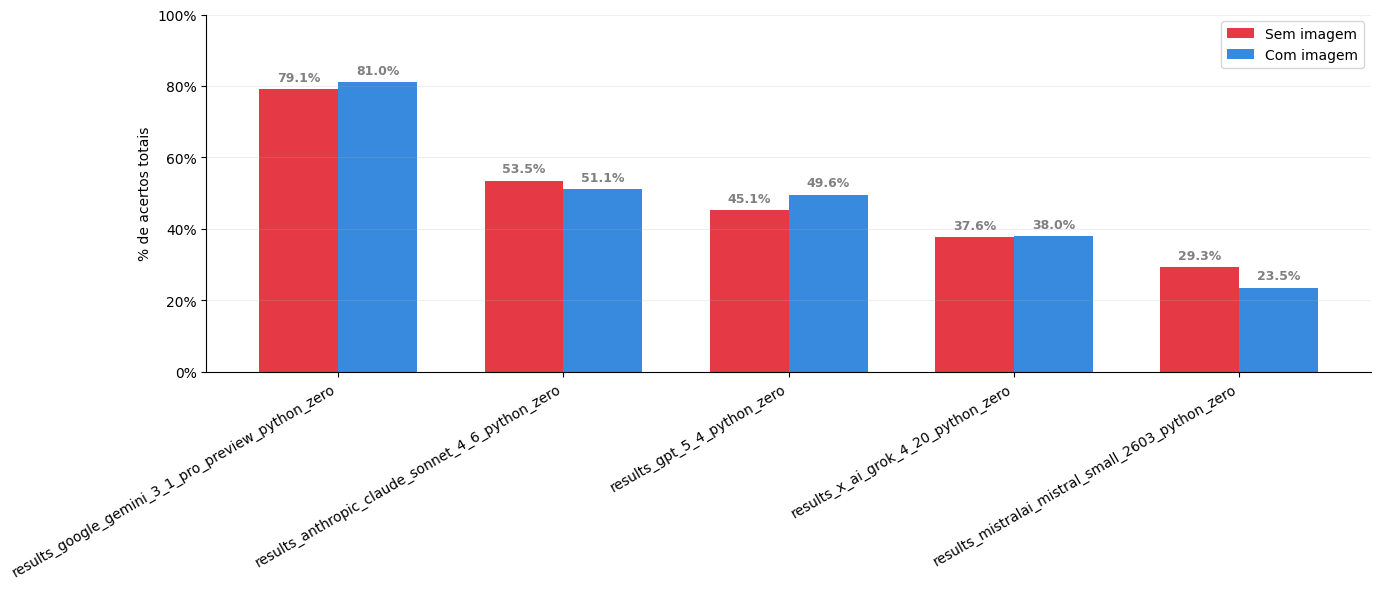

In [77]:
len_g = total_test_cases['g']
len_pd = total_test_cases['pd']
total_len = len_g + len_pd

base_models = set()
for k in data_by_dataset.keys():
    if k.endswith('_noimg'):
        base_models.add(k.replace('_noimg', ''))
    elif k.endswith('_img'):
        base_models.add(k.replace('_img', ''))

def get_total_base(base):
    t = 0
    if base + '_noimg' in data_by_dataset:
        t += data_by_dataset[base + '_noimg']['g'] + data_by_dataset[base + '_noimg']['pd']
    if base + '_img' in data_by_dataset:
        t += data_by_dataset[base + '_img']['g'] + data_by_dataset[base + '_img']['pd']
    return t

modelos_sorted = sorted(list(base_models), key=get_total_base, reverse=True)

pct_noimg = []
pct_img = []

for base in modelos_sorted:
    k_noimg = base + '_noimg'
    k_img = base + '_img'
    
    if k_noimg in data_by_dataset:
        total_acertos = data_by_dataset[k_noimg]['g'] + data_by_dataset[k_noimg]['pd']
        pct_noimg.append(total_acertos / total_len * 100)
    else:
        pct_noimg.append(0)
        
    # Preenche dados Com Imagem (ou 0 se não existir)
    if k_img in data_by_dataset:
        total_acertos = data_by_dataset[k_img]['g'] + data_by_dataset[k_img]['pd']
        pct_img.append(total_acertos / total_len * 100)
    else:
        pct_img.append(0)

x = np.arange(len(modelos_sorted))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

bars_noimg = ax.bar(x - w/2, pct_noimg, w, label='Sem imagem', color='#E63946')

bars_img = ax.bar(x + w/2, pct_img, w, label='Com imagem', color='#378ADD')

for i in range(len(modelos_sorted)):
    if pct_noimg[i] > 0:
        ax.text(x[i] - w/2, pct_noimg[i] + 1.5, f'{pct_noimg[i]:.1f}%',
                ha='center', va='bottom', fontsize=9, color='gray', fontweight='bold')
    
    if pct_img[i] > 0:
        ax.text(x[i] + w/2, pct_img[i] + 1.5, f'{pct_img[i]:.1f}%',
                ha='center', va='bottom', fontsize=9, color='gray', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(modelos_sorted, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('% de acertos totais')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))

ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()